In [9]:
# Step 1: Import required libraries
import pandas as pd
import spacy
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the English NLP model
nlp = spacy.load("en_core_web_sm")


In [11]:
# Step 2: Load dataset and inspect structure
df = pd.read_csv("../datasets/amazon_reviews.csv", usecols=["name", "brand", "reviews.text"])

# Drop any rows with missing review text
df = df.dropna(subset=["reviews.text"]).reset_index(drop=True)

# Quick look at data
print("Number of reviews:", len(df))
df.head()


Number of reviews: 1597


,brand,name,reviews.text
0,Amazon,Kindle Paperwhite,I initially had trouble deciding between the p...
1,Amazon,Kindle Paperwhite,Allow me to preface this with a little history...
2,Amazon,Kindle Paperwhite,I am enjoying it so far. Great for reading. Ha...
3,Amazon,Kindle Paperwhite,I bought one of the first Paperwhites and have...
4,Amazon,Kindle Paperwhite,I have to say upfront - I don't like coroporat...


In [12]:
# Step 3: Perform Named Entity Recognition (NER) and Sentiment Analysis

results = []

for i, row in df.head(10).iterrows():   # Analyze only first 10 for clarity
    text = row["reviews.text"]
    doc = nlp(text)
    
    # Named Entities
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    
    # Sentiment (using TextBlob)
    sentiment = TextBlob(text).sentiment.polarity
    sentiment_label = "Positive" if sentiment > 0 else "Negative" if sentiment < 0 else "Neutral"
    
    results.append({
        "Product": row["name"],
        "Brand": row["brand"],
        "Review": text[:150] + "...",
        "Entities": entities,
        "Sentiment": sentiment_label,
        "Polarity": sentiment
    })
    
# Convert results to DataFrame for preview
output_df = pd.DataFrame(results)
output_df


,Product,Brand,Review,Entities,Sentiment,Polarity
0,Kindle Paperwhite,Amazon,I initially had trouble deciding between the p...,"[(300, CARDINAL), (80 dollar, MONEY), (a week,...",Positive,0.200259
1,Kindle Paperwhite,Amazon,Allow me to preface this with a little history...,"[(a Nook Simple Touch, PERSON), (2011, DATE), ...",Positive,0.159591
2,Kindle Paperwhite,Amazon,I am enjoying it so far. Great for reading. Ha...,"[(2012, DATE), (Paperwhite, PERSON)]",Positive,0.420833
3,Kindle Paperwhite,Amazon,I bought one of the first Paperwhites and have...,"[(first, ORDINAL), (every three days, DATE), (...",Positive,0.148821
4,Kindle Paperwhite,Amazon,I have to say upfront - I don't like coroporat...,"[(Apple, ORG), (Amazon, ORG), (a Nook Touch, W...",Positive,0.267086
5,Kindle Paperwhite,Amazon,"My previous kindle was a DX, this is my second...","[(second, ORDINAL), (years, DATE), (English, L...",Positive,0.006944
6,Kindle Paperwhite,Amazon,Allow me to preface this with a little history...,"[(a Nook Simple Touch, PERSON), (2011, DATE), ...",Positive,0.159591
7,Kindle Paperwhite,Amazon,Just got mine right now. Looks the same as the...,"[(Kindle, LOC), (300, CARDINAL), (4, CARDINAL)...",Positive,0.113237
8,Kindle Paperwhite,Amazon,I initially had trouble deciding between the p...,"[(300, CARDINAL), (80 dollar, MONEY), (a week,...",Positive,0.200259
9,Kindle Paperwhite,Amazon,I am enjoying it so far. Great for reading. Ha...,"[(2012, DATE), (Paperwhite, PERSON)]",Positive,0.420833


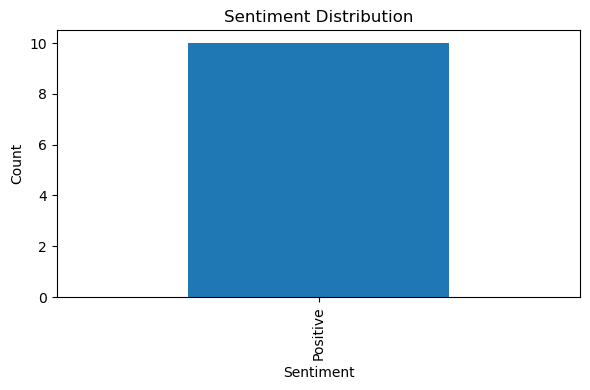

In [13]:
# Step 4: Visualize how many reviews are Positive, Neutral, or Negative

sentiment_counts = output_df["Sentiment"].value_counts()
sentiment_counts.plot(kind="bar", title="Sentiment Distribution", figsize=(6,4))
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../results/spacy_ner_output.png")
plt.show()


In [14]:
# Step 5: Save results to CSV for report inclusion
output_df.to_csv("../results/spacy_ner_results.csv", index=False)
print("Results saved to ../results/spacy_ner_results.csv")


Results saved to ../results/spacy_ner_results.csv
